In [ ]:
import pandas as pd
import numpy as np


Data = pd.read_csv("/home/tejas/Desktop/phish_dataset/New_NetPhish_Versions/NetPhish_2_V2.csv")
display(Data.head())
Data.shape

,URL,url_length,num_dots,has_hyphen,has_at_symbol,path_length,query_length,num_params,tld_length,uses_https,...,num_unique_chars,has_hex_chars,file_extension_length,num_underscores,asn,reverse_dns_present,organisation,dnssec,is_netblock_trusted,class
0,https://www.arenaliving.sg/products/casa-chair...,60,2,0,0,34,0,0,2,1,...,21,0,0,0,13335,1,0,1,1,0
1,http://instagram-v2-jet.vercel.app,34,2,1,0,0,0,0,3,0,...,20,0,0,0,16509,0,1,1,0,1
2,https://tngirlapparel.com/products/let-it-bee-...,72,1,0,0,47,0,0,3,1,...,22,0,0,0,13335,1,0,1,1,0
3,https://www.one-2-one.pl/co-zamiast-sport-trac...,51,2,1,0,27,0,0,2,1,...,21,0,0,0,57367,1,0,1,0,0
4,https://mendezroldan.com/subvenciones-para-la-...,53,4,0,0,14,10,1,5,1,...,25,0,3,0,786,1,1,1,0,0


(67140, 32)

### **EDA of Dataset**

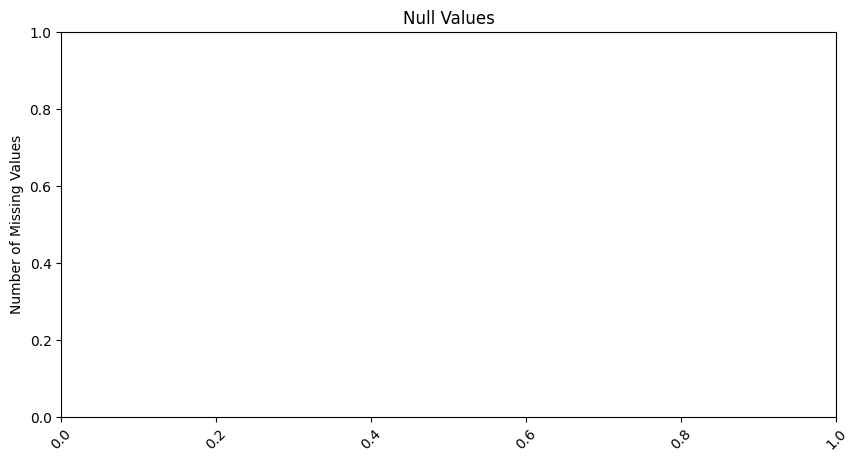

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

null = Data.isnull().sum()
null_value = null[null > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=null_value.index, y=null_value.values)
plt.title('Null Values')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

In [69]:
from scipy import stats

num_cols = Data.select_dtypes(include=np.number).columns.tolist()
outlier_counts = {}

for col in num_cols:
    if Data[col].nunique() > 10:
        z = np.abs(stats.zscore(Data[col].dropna()))
        outlier_counts[col] = (z > 3).sum()

outlier = pd.DataFrame(list(outlier_counts.items()), columns=['Feature name', 'Outlier Count'])
outlier = outlier.sort_values('Outlier Count', ascending=False)
print(outlier)


             Feature name  Outlier Count
5              tld_length           2819
15                    asn           2452
12       num_unique_chars           1294
11  digit_to_length_ratio           1203
9       num_special_chars           1017
1                num_dots            986
2             path_length            890
7           domain_length            795
8         hostname_length            779
4              num_params            691
0              url_length            619
3            query_length            587
6               url_depth            557
14        num_underscores            379
13  file_extension_length            366
10        fragment_length            199


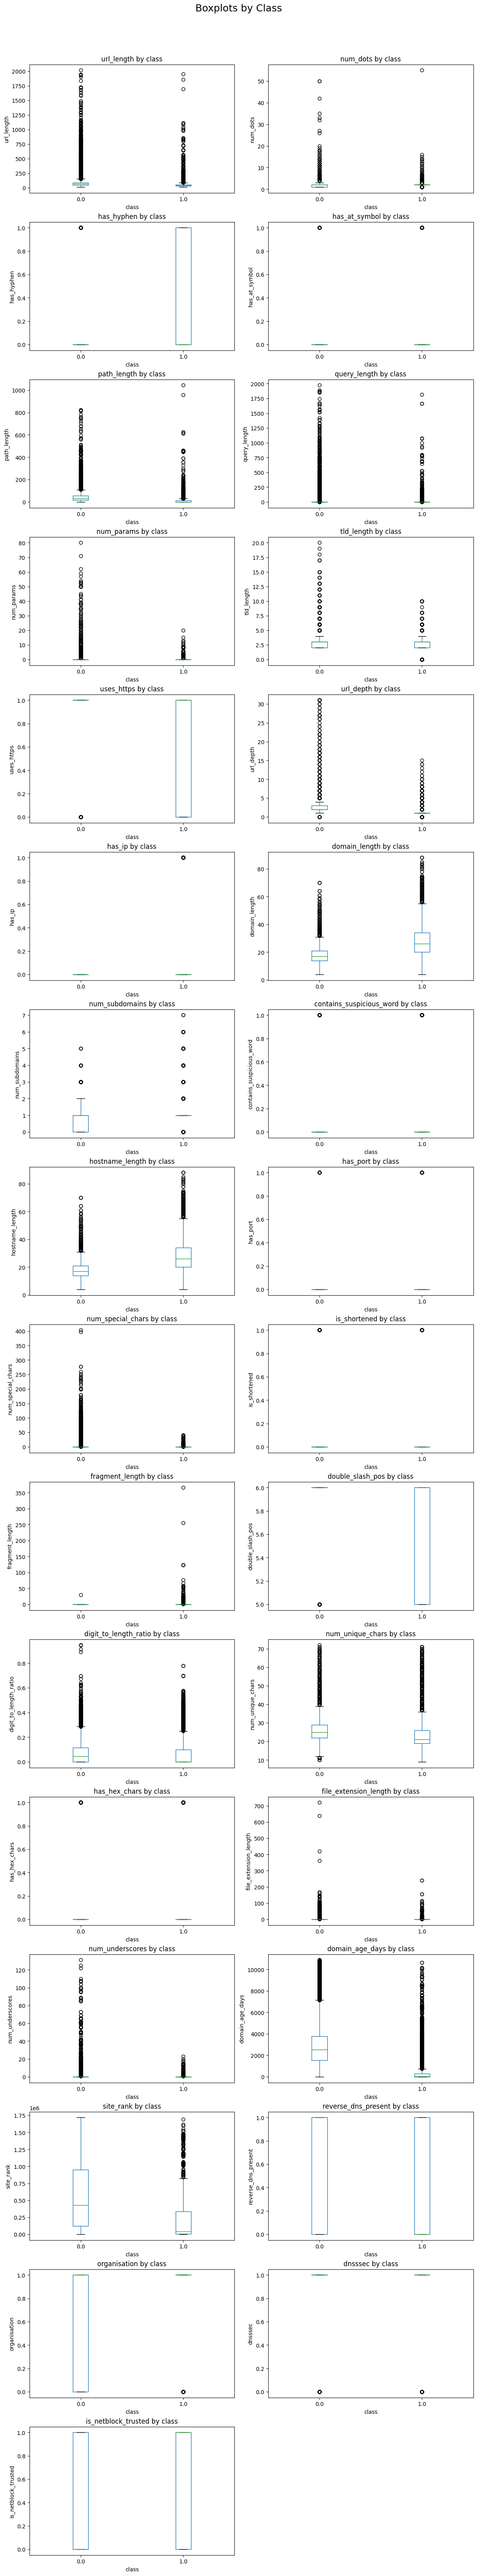

In [54]:
import math

# Filter numeric features
numeric = Data.select_dtypes(include=np.number).columns.tolist()
if 'class' in numeric:
    numeric.remove('class')

n_cols = 2
n_plots = len(numeric)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows), constrained_layout=True)
for i, col in enumerate(numeric):
    ax = axes[i // n_cols, i % n_cols] if n_rows > 1 else axes[i % n_cols]
    Data.boxplot(column=col, by='class', grid=False, ax=ax)
    ax.set_title(f"{col} by class")
    ax.set_xlabel("class")
    ax.set_ylabel(col)

for j in range(n_plots, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

fig.suptitle('Boxplots by Class', fontsize=18, y=1.02)
plt.show()


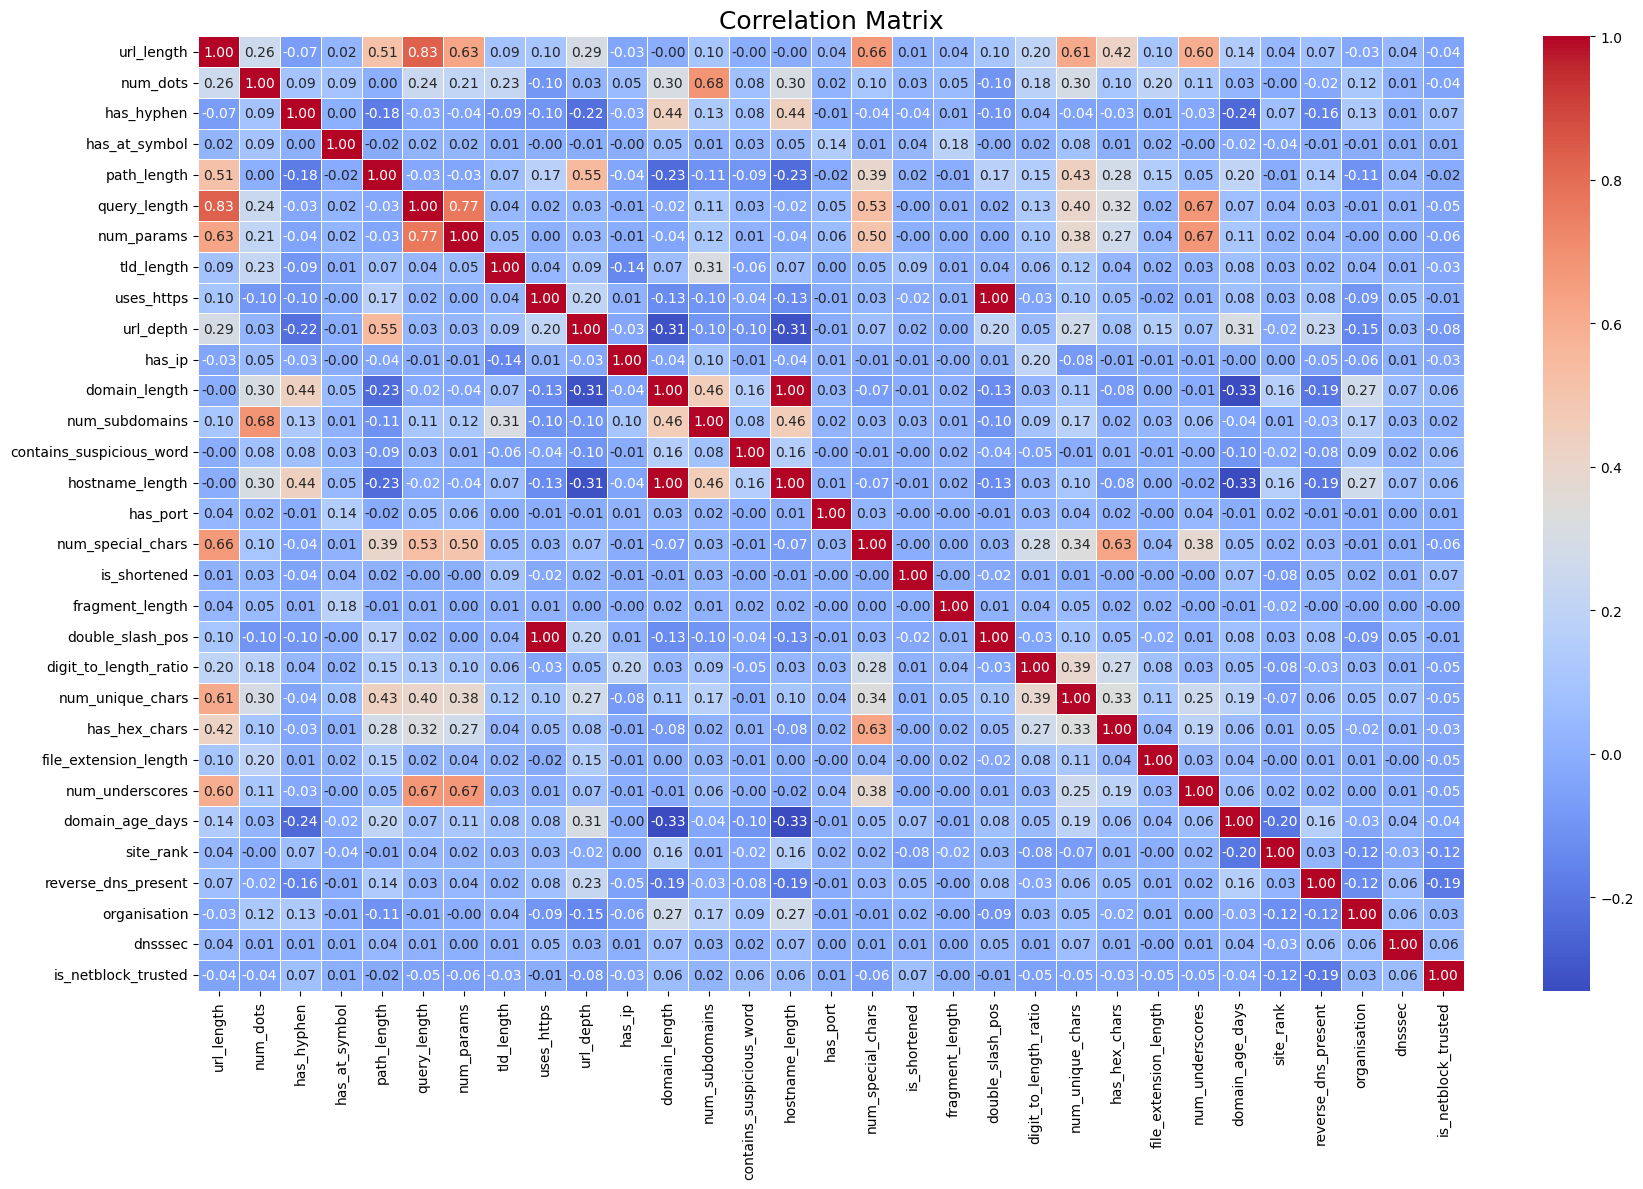

In [55]:
corr = Data[numeric].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=18)
plt.tight_layout()
plt.show()


In [56]:
corr_pairs = corr.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs.index = [tuple(sorted(pair)) for pair in corr_pairs.index]
corr_pairs = corr_pairs[~corr_pairs.index.duplicated(keep='first')]
corr_pairs = corr_pairs.reindex(corr_pairs.abs().sort_values(ascending=False).index)

print("Positive correlation scores:\n")
for (feature1, feature2), score in corr_pairs.items():
    if score > 0:
        print(f"{feature1:25} {feature2:25} {score:.4f}")


Positive correlation scores:

domain_length             hostname_length           0.9996
double_slash_pos          uses_https                0.9982
query_length              url_length                0.8311
num_params                query_length              0.7669
num_dots                  num_subdomains            0.6835
num_params                num_underscores           0.6738
num_underscores           query_length              0.6732
num_special_chars         url_length                0.6636
has_hex_chars             num_special_chars         0.6285
num_params                url_length                0.6279
num_unique_chars          url_length                0.6122
num_underscores           url_length                0.5983
path_length               url_depth                 0.5476
num_special_chars         query_length              0.5280
path_length               url_length                0.5122
num_params                num_special_chars         0.5014
domain_length             

Class Feature:
class
0.0    52356
1.0    33570
Name: count, dtype: int64
class
0.0    60.931499
1.0    39.068501
Name: proportion, dtype: float64


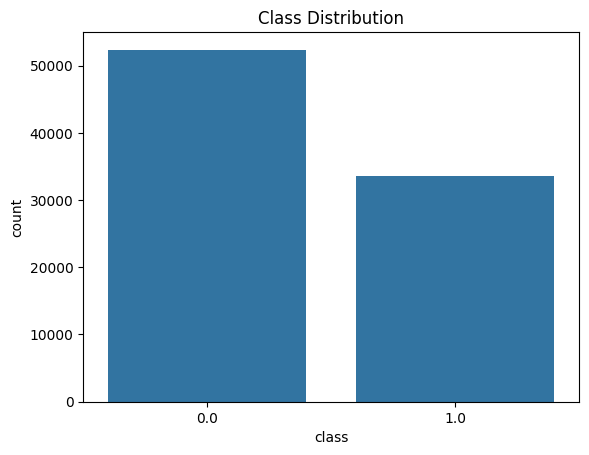

In [57]:
print("Class Feature:")
print(Data['class'].value_counts())
print(Data['class'].value_counts(normalize=True) * 100)

sns.countplot(x='class', data=Data)
plt.title("Class Distribution")
plt.show()


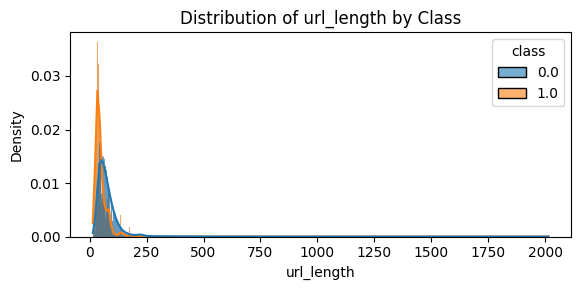

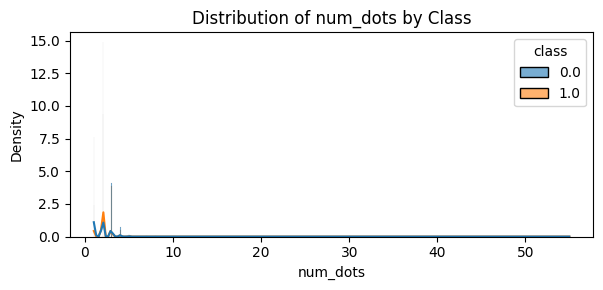

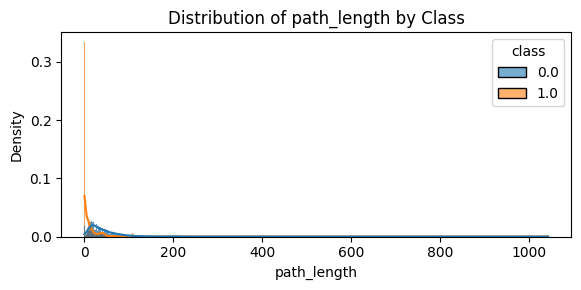

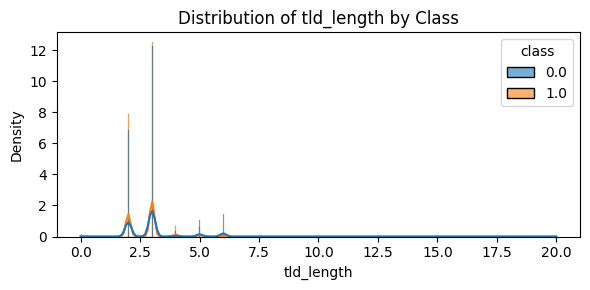

In [58]:
features_to_plot = ['url_length', 'num_dots', 'path_length', 'tld_length']  # Modify based on your dataset

for col in features_to_plot:
    if col in Data.columns:
        plt.figure(figsize=(6,3))
        sns.histplot(data=Data, x=col,
                     hue='class', kde=True, stat='density',
                     common_norm=False, alpha=0.6)
        plt.title(f'Distribution of {col} by Class')
        plt.xlabel(col)
        plt.ylabel('Density')
        plt.tight_layout()
        plt.show()


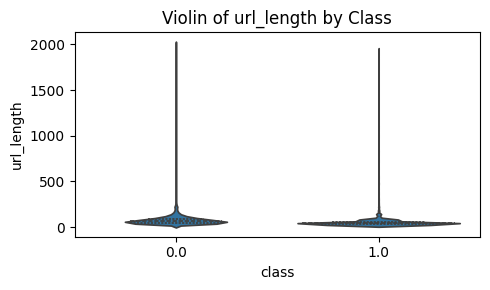

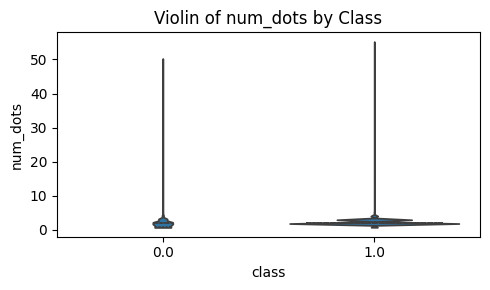

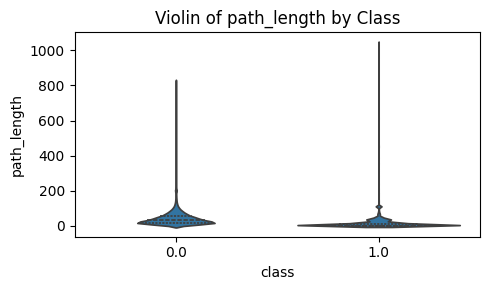

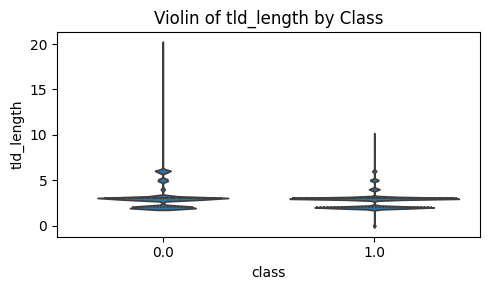

In [59]:
for col in features_to_plot:
    if col in Data.columns:
        plt.figure(figsize=(5,3))
        sns.violinplot(data=Data, x='class', y=col, inner='quartile')
        plt.title(f'Violin of {col} by Class')
        plt.xlabel('class')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()


Top features by |corr| with class:
 url_depth              0.510194
domain_length          0.494139
hostname_length        0.494048
domain_age_days        0.480109
path_length            0.394371
has_hyphen             0.330684
organisation           0.281987
reverse_dns_present    0.281464
uses_https             0.242761
double_slash_pos       0.242221
dtype: float64


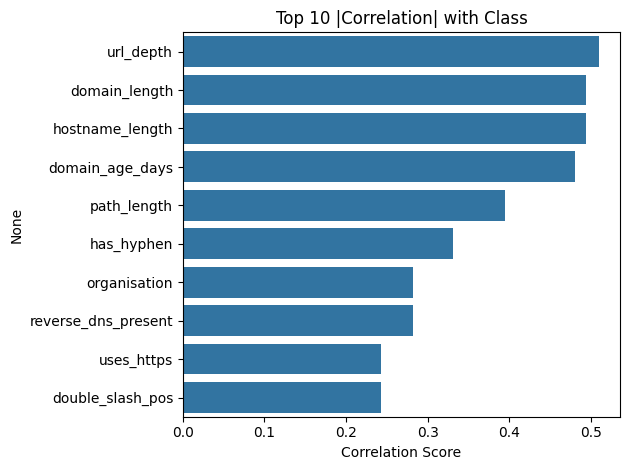

In [60]:
corr_series = Data[numeric].corrwith(Data['class']).abs().sort_values(ascending=False)
print("Top features by |corr| with class:\n", corr_series.head(10))

sns.barplot(x=corr_series.head(10).values, y=corr_series.head(10).index)
plt.title("Top 10 |Correlation| with Class")
plt.xlabel("Correlation Score")
plt.tight_layout()
plt.show()


## **Preprocessing of Dataset**


In [61]:
Data.drop_duplicates(subset="URL", inplace=True)
print(f"Data shape after dropping duplicates: {Data.shape}")

Data shape after dropping duplicates: (85926, 35)


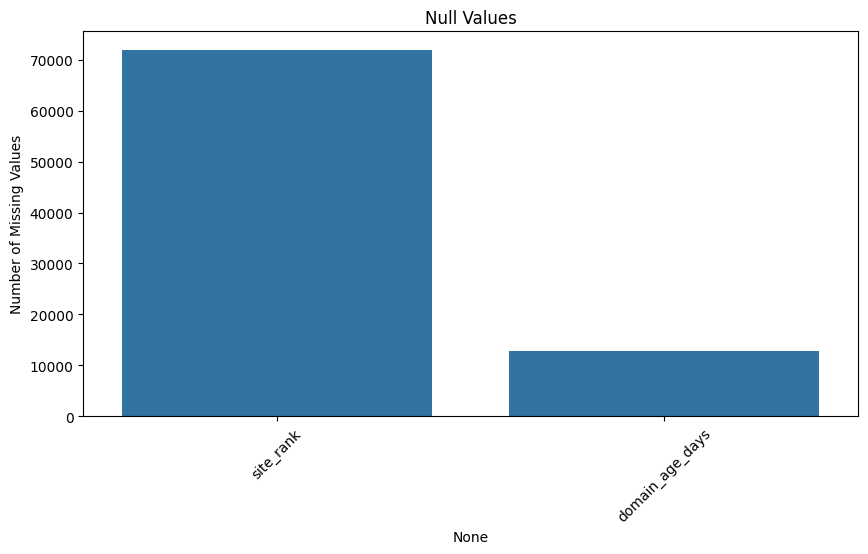

In [62]:
null = Data.isnull().sum()
null_value = null[null > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=null_value.index, y=null_value.values)
plt.title('Null Values')
plt.ylabel('Number of Missing Values')
plt.xticks(rotation=45)
plt.show()

In [63]:
phishing = Data[Data['class'] == 1]
legit = Data[(Data['class'] == 0)].sample(n=33570, random_state=42)
balanced = pd.concat([phishing, legit], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)
balanced = balanced.drop(['domain_age_days', 'site_rank','netblock_owner'], axis=1, errors='ignore')
balanced['asn'] = balanced['asn'].astype(str).str.replace(r'^AS', '', case=False, regex=True)

print(balanced['class'].value_counts())

class
0.0    33570
1.0    33570
Name: count, dtype: int64


In [64]:
import csv


In [65]:
balanced.to_csv('/home/tejas/Desktop/phish_dataset/New_NetPhish_Versions/NetPhish_2_V3.csv', quoting=csv.QUOTE_ALL, encoding='utf-8',index=False)

In [66]:
print(balanced.shape)

(67140, 32)
